In [ ]:
import os

PROJECT_DIR = '/content/drive/MyDrive/SIT210_PlantDisease'
os.makedirs(PROJECT_DIR, exist_ok=True)
os.makedirs(f'{PROJECT_DIR}/dataset', exist_ok=True)
os.makedirs(f'{PROJECT_DIR}/models', exist_ok=True)

print("✅ Project directory created!")

✅ Project directory created!


In [ ]:
# Cài thư viện Kaggle
!pip install kaggle -q

In [ ]:
!kaggle datasets download -d abdallahalidev/plantvillage-dataset --unzip

Dataset URL: https://www.kaggle.com/datasets/abdallahalidev/plantvillage-dataset
License(s): CC-BY-NC-SA-4.0
100% 2.04G/2.04G [00:13<00:00, 168MB/s]



In [ ]:
import os

# Tìm xem dataset ở đâu
for root, dirs, files in os.walk('/content'):
    # Chỉ xem 2 levels đầu
    level = root.replace('/content', '').count(os.sep)
    if level < 3:
        indent = ' ' * 2 * level
        print(f'{indent}{os.path.basename(root)}/')

content/
  .config/
    configurations/
    logs/
  drive/
    .shortcut-targets-by-id/
    MyDrive/
    .Trash-0/
  plantvillage dataset/
    segmented/
    color/
    grayscale/
  sample_data/


In [ ]:
dataset_base = '/content/plantvillage dataset/color'

all_classes = sorted(os.listdir(dataset_base))
print(f"Total classes: {len(all_classes)}\n")
for i, cls in enumerate(all_classes):
    count = len(os.listdir(f'{dataset_base}/{cls}'))
    print(f"  {i+1:2d}. {cls}: {count} images")

Total classes: 38

   1. Apple___Apple_scab: 630 images
   2. Apple___Black_rot: 621 images
   3. Apple___Cedar_apple_rust: 275 images
   4. Apple___healthy: 1645 images
   5. Blueberry___healthy: 1502 images
   6. Cherry_(including_sour)___Powdery_mildew: 1052 images
   7. Cherry_(including_sour)___healthy: 854 images
   8. Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot: 513 images
   9. Corn_(maize)___Common_rust_: 1192 images
  10. Corn_(maize)___Northern_Leaf_Blight: 985 images
  11. Corn_(maize)___healthy: 1162 images
  12. Grape___Black_rot: 1180 images
  13. Grape___Esca_(Black_Measles): 1383 images
  14. Grape___Leaf_blight_(Isariopsis_Leaf_Spot): 1076 images
  15. Grape___healthy: 423 images
  16. Orange___Haunglongbing_(Citrus_greening): 5507 images
  17. Peach___Bacterial_spot: 2297 images
  18. Peach___healthy: 360 images
  19. Pepper,_bell___Bacterial_spot: 997 images
  20. Pepper,_bell___healthy: 1478 images
  21. Potato___Early_blight: 1000 images
  22. Potato___Late

In [ ]:
import shutil
from sklearn.model_selection import train_test_split

PREPARED_DIR = f'{PROJECT_DIR}/dataset/prepared'

# Tạo thư mục cho tất cả classes
for split in ['train', 'val', 'test']:
    for cls in all_classes:
        os.makedirs(f'{PREPARED_DIR}/{split}/{cls}', exist_ok=True)

# Split 70/15/15
for cls in all_classes:
    src = f'{dataset_base}/{cls}'
    images = os.listdir(src)

    train_imgs, temp = train_test_split(images, test_size=0.3, random_state=42)
    val_imgs, test_imgs = train_test_split(temp, test_size=0.5, random_state=42)

    for img in train_imgs:
        shutil.copy(f'{src}/{img}', f'{PREPARED_DIR}/train/{cls}/{img}')
    for img in val_imgs:
        shutil.copy(f'{src}/{img}', f'{PREPARED_DIR}/val/{cls}/{img}')
    for img in test_imgs:
        shutil.copy(f'{src}/{img}', f'{PREPARED_DIR}/test/{cls}/{img}')

print(f"✅ Done! {len(all_classes)} classes organized.")

✅ Done! 38 classes organized.


In [ ]:
import tensorflow as tf
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau

IMG_SIZE = 224
BATCH_SIZE = 32
NUM_CLASSES = 38

print(f"✅ TensorFlow {tf.__version__} ready!")
print(f"✅ GPU: {tf.config.list_physical_devices('GPU')}")

✅ TensorFlow 2.19.0 ready!
✅ GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [ ]:
base_model = MobileNetV2(
    input_shape=(IMG_SIZE, IMG_SIZE, 3),
    include_top=False,
    weights='imagenet'
)
base_model.trainable = False

x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dropout(0.3)(x)
x = Dense(256, activation='relu')(x)   # ← 256 vì 38 classes phức tạp hơn
x = Dropout(0.2)(x)
output = Dense(NUM_CLASSES, activation='softmax')(x)  # ← 38

model = Model(inputs=base_model.input, outputs=output)
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)
print(f"✅ Model built for {NUM_CLASSES} classes")

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
✅ Model built for 38 classes


In [ ]:
from sklearn.model_selection import train_test_split

PREPARED_DIR = f'{PROJECT_DIR}/dataset/prepared'

train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    horizontal_flip=True,
    zoom_range=0.2,
    fill_mode='nearest'
)
val_datagen = ImageDataGenerator(rescale=1./255)

train_gen = train_datagen.flow_from_directory(
    f'{PREPARED_DIR}/train',
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical'
)
val_gen = val_datagen.flow_from_directory(
    f'{PREPARED_DIR}/val',
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical'
)
test_gen = val_datagen.flow_from_directory(
    f'{PREPARED_DIR}/test',
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

print(f"✅ Train: {train_gen.n} | Val: {val_gen.n} | Test: {test_gen.n}")

Found 37998 images belonging to 38 classes.
Found 8145 images belonging to 38 classes.
Found 8162 images belonging to 38 classes.
✅ Train: 37998 | Val: 8145 | Test: 8162


In [ ]:

from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau

callbacks = [
    ModelCheckpoint(
        f'{PROJECT_DIR}/models/best_model.h5',
        monitor='val_accuracy',
        save_best_only=True,
        verbose=1
    ),
    ModelCheckpoint(
        f'{PROJECT_DIR}/models/checkpoint_epoch{{epoch:02d}}.h5',
        save_freq='epoch'
    ),

        factor=0.5,
        patience=3,
        min_lr=1e-7,
        verbose=1
    )
]
print("✅ Callbacks ready!")

✅ Callbacks ready!


In [ ]:
print("🚀 Training Phase A (frozen base)...")
history_a = model.fit(
    train_gen,
    epochs=10,
    validation_data=val_gen,
    callbacks=callbacks,
    verbose=1
)

🚀 Training Phase A (frozen base)...
Epoch 1/10
1188/1188 ━━━━━━━━━━━━━━━━━━━━ 0s 525ms/step - accuracy: 0.6765 - loss: 1.1624
Epoch 1: val_accuracy improved from None to 0.89871, saving model to /content/drive/MyDrive/SIT210_PlantDisease/models/best_model.h5



Epoch 1: finished saving model to /content/drive/MyDrive/SIT210_PlantDisease/models/best_model.h5


1188/1188 ━━━━━━━━━━━━━━━━━━━━ 730s 597ms/step - accuracy: 0.7770 - loss: 0.7396 - val_accuracy: 0.8987 - val_loss: 0.3198 - learning_rate: 0.0010
Epoch 2/10
1188/1188 ━━━━━━━━━━━━━━━━━━━━ 0s 527ms/step - accuracy: 0.8586 - loss: 0.4394
Epoch 2: val_accuracy improved from 0.89871 to 0.91209, saving model to /content/drive/MyDrive/SIT210_PlantDisease/models/best_model.h5



Epoch 2: finished saving model to /content/drive/MyDrive/SIT210_PlantDisease/models/best_model.h5


1188/1188 ━━━━━━━━━━━━━━━━━━━━ 664s 559ms/step - accuracy: 0.8628 - loss: 0.4251 - val_accuracy: 0.9121 - val_loss: 0.2657 - learning_rate: 0.0010
Epoch 3/10
1188/1188 ━━━━━━━━━━━━━━━━━━━━ 0s 523ms/step - accuracy: 0.8708 - loss: 0.3901
Epoch 3: val_accuracy improved from 0.91209 to 0.91762, saving model to /content/drive/MyDrive/SIT210_PlantDisease/models/best_model.h5


...


Epoch 7: finished saving model to /content/drive/MyDrive/SIT210_PlantDisease/models/best_model.h5


1188/1188 ━━━━━━━━━━━━━━━━━━━━ 629s 529ms/step - accuracy: 0.8921 - loss: 0.3274 - val_accuracy: 0.9315 - val_loss: 0.2004 - learning_rate: 0.0010
Epoch 8/10
1188/1188 ━━━━━━━━━━━━━━━━━━━━ 0s 492ms/step - accuracy: 0.8953 - loss: 0.3178
Epoch 8: val_accuracy did not improve from 0.93149


1188/1188 ━━━━━━━━━━━━━━━━━━━━ 614s 517ms/step - accuracy: 0.8956 - loss: 0.3146 - val_accuracy: 0.9239 - val_loss: 0.2164 - learning_rate: 0.0010
Epoch 9/10
1188/1188 ━━━━━━━━━━━━━━━━━━━━ 0s 488ms/step - accuracy: 0.8938 - loss: 0.3143
Epoch 9: val_accuracy did not improve from 0.93149


1188/1188 ━━━━━━━━━━━━━━━━━━━━ 611s 515ms/step - accuracy: 0.8967 - loss: 0.3074 - val_accuracy: 0.9273 - val_loss: 0.2143 - learning_rate: 0.0010
Epoch 10/10
1188/1188 ━━━━━━━━━━━━━━━━━━━━ 0s 494ms/step - accuracy: 0.9013 - loss: 0.2958
Epoch 10: val_accuracy did not improve from 0.93149


1188/1188 ━━━━━━━━━━━━━━━━━━━━ 618s 520ms/step - accuracy: 0.8985 - loss: 0.3075 - val_accuracy: 0.9306 - val_loss: 0.1991 - learning_rate: 0.0010


In [ ]:
import json
with open(f'{PROJECT_DIR}/models/class_names.json', 'w') as f:
    json.dump({str(v): k for k, v in train_gen.class_indices.items()}, f, indent=2)
print("✅ Done!")


✅ Done!


In [ ]:
import os

models_dir = f'{PROJECT_DIR}/models'
print("📁 Files trong Drive/SIT210_PlantDisease/models/:")
for f in sorted(os.listdir(models_dir)):
    size = os.path.getsize(f'{models_dir}/{f}') / (1024*1024)
    print(f"  {f}: {size:.1f} MB")

📁 Files trong Drive/SIT210_PlantDisease/models/:
  best_model.h5: 13.0 MB
  checkpoint_epoch01.h5: 13.0 MB
  checkpoint_epoch02.h5: 13.0 MB
  checkpoint_epoch03.h5: 13.0 MB
  checkpoint_epoch04.h5: 13.0 MB
  checkpoint_epoch05.h5: 13.0 MB
  checkpoint_epoch06.h5: 13.0 MB
  checkpoint_epoch07.h5: 13.0 MB
  checkpoint_epoch08.h5: 13.0 MB
  checkpoint_epoch09.h5: 13.0 MB
  checkpoint_epoch10.h5: 13.0 MB
  class_names.json: 0.0 MB


In [ ]:
from google.colab import drive
drive.mount('/content/drive')
import os
PROJECT_DIR = '/content/drive/MyDrive/SIT210_PlantDisease'
print("✅ Drive mounted!")

Mounted at /content/drive
✅ Drive mounted!


In [ ]:
import tensorflow as tf
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.models import Model, load_model
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau

IMG_SIZE = 224
BATCH_SIZE = 32
NUM_CLASSES = 38
print(f"✅ TF {tf.__version__}")

✅ TF 2.19.0


In [ ]:
!pip install kaggle -q
# Upload kaggle.json khi được hỏi
from google.colab import files
files.upload()
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json
!kaggle datasets download -d abdallahalidev/plantvillage-dataset --unzip
print("✅ Dataset ready!")

Saving kaggle.json to kaggle.json
Dataset URL: https://www.kaggle.com/datasets/abdallahalidev/plantvillage-dataset
License(s): CC-BY-NC-SA-4.0
100% 2.04G/2.04G [00:15<00:00, 137MB/s]

✅ Dataset ready!


In [ ]:
model = load_model(f'{PROJECT_DIR}/models/best_model.h5')
print("✅ Model loaded! Tiếp tục từ val_accuracy 93.3%")

callbacks = [
    ModelCheckpoint(
        f'{PROJECT_DIR}/models/best_model.h5',
        monitor='val_accuracy', save_best_only=True, verbose=1
    ),
    ModelCheckpoint(
        f'{PROJECT_DIR}/models/checkpoint_epoch{{epoch:02d}}.h5',
        save_freq='epoch'
    ),
    EarlyStopping(monitor='val_accuracy', patience=5, restore_best_weights=True),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-7, verbose=1)
]
print("✅ Callbacks ready!")

✅ Model loaded! Tiếp tục từ val_accuracy 93.3%
✅ Callbacks ready!


In [ ]:
base_model = model.layers[1]
base_model.trainable = True
for layer in base_model.layers[:-30]:
    layer.trainable = False

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print("🚀 Training Phase B (fine-tuning)...")
history_b = model.fit(
    train_gen, epochs=10,
    validation_data=val_gen,
    callbacks=callbacks, verbose=1
)

AttributeError: 'Conv2D' object has no attribute 'layers'

In [ ]:
# Tìm đúng MobileNetV2 layer
for i, layer in enumerate(model.layers):
    print(f"{i}: {layer.name} — {type(layer).__name__}")

0: input_layer — InputLayer
1: Conv1 — Conv2D
2: bn_Conv1 — BatchNormalization
3: Conv1_relu — ReLU
4: expanded_conv_depthwise — DepthwiseConv2D
5: expanded_conv_depthwise_BN — BatchNormalization
6: expanded_conv_depthwise_relu — ReLU
7: expanded_conv_project — Conv2D
8: expanded_conv_project_BN — BatchNormalization
9: block_1_expand — Conv2D
10: block_1_expand_BN — BatchNormalization
11: block_1_expand_relu — ReLU
12: block_1_pad — ZeroPadding2D
13: block_1_depthwise — DepthwiseConv2D
14: block_1_depthwise_BN — BatchNormalization
15: block_1_depthwise_relu — ReLU
16: block_1_project — Conv2D
17: block_1_project_BN — BatchNormalization
18: block_2_expand — Conv2D
19: block_2_expand_BN — BatchNormalization
20: block_2_expand_relu — ReLU
21: block_2_depthwise — DepthwiseConv2D
22: block_2_depthwise_BN — BatchNormalization
23: block_2_depthwise_relu — ReLU
24: block_2_project — Conv2D
25: block_2_project_BN — BatchNormalization
26: block_2_add — Add
27: block_3_expand — Conv2D
28: block_3

In [ ]:
PREPARED_DIR = f'{PROJECT_DIR}/dataset/prepared'

train_datagen = ImageDataGenerator(
    rescale=1./255, rotation_range=20,
    width_shift_range=0.2, height_shift_range=0.2,
    horizontal_flip=True, zoom_range=0.2, fill_mode='nearest'
)
val_datagen = ImageDataGenerator(rescale=1./255)

train_gen = train_datagen.flow_from_directory(
    f'{PREPARED_DIR}/train',
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE, class_mode='categorical'
)
val_gen = val_datagen.flow_from_directory(
    f'{PREPARED_DIR}/val',
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE, class_mode='categorical'
)
print(f"✅ Train: {train_gen.n} | Val: {val_gen.n}")

Found 37998 images belonging to 38 classes.
Found 8145 images belonging to 38 classes.
✅ Train: 37998 | Val: 8145


In [ ]:
!kaggle datasets download -d abdallahalidev/plantvillage-dataset --unzip
print("✅ Downloaded to /content/plantvillage-dataset/")

Dataset URL: https://www.kaggle.com/datasets/abdallahalidev/plantvillage-dataset
License(s): CC-BY-NC-SA-4.0
100% 2.04G/2.04G [00:19<00:00, 110MB/s]

✅ Downloaded to /content/plantvillage-dataset/


In [ ]:
import shutil
from sklearn.model_selection import train_test_split

dataset_base = '/content/plantvillage dataset/color'
PREPARED_DIR = '/content/prepared'

all_classes = sorted(os.listdir(dataset_base))

for split in ['train', 'val', 'test']:
    for cls in all_classes:
        os.makedirs(f'{PREPARED_DIR}/{split}/{cls}', exist_ok=True)

for cls in all_classes:
    src = f'{dataset_base}/{cls}'
    images = os.listdir(src)
    train_imgs, temp = train_test_split(images, test_size=0.3, random_state=42)
    val_imgs, test_imgs = train_test_split(temp, test_size=0.5, random_state=42)

    for img in train_imgs:
        shutil.copy(f'{src}/{img}', f'{PREPARED_DIR}/train/{cls}/{img}')
    for img in val_imgs:
        shutil.copy(f'{src}/{img}', f'{PREPARED_DIR}/val/{cls}/{img}')
    for img in test_imgs:
        shutil.copy(f'{src}/{img}', f'{PREPARED_DIR}/test/{cls}/{img}')

print(f"✅ Done! {len(all_classes)} classes organized.")

✅ Done! 38 classes organized.


In [ ]:
train_datagen = ImageDataGenerator(
    rescale=1./255, rotation_range=20,
    width_shift_range=0.2, height_shift_range=0.2,
    horizontal_flip=True, zoom_range=0.2, fill_mode='nearest'
)
val_datagen = ImageDataGenerator(rescale=1./255)

train_gen = train_datagen.flow_from_directory(
    f'{PREPARED_DIR}/train',
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE, class_mode='categorical'
)
val_gen = val_datagen.flow_from_directory(
    f'{PREPARED_DIR}/val',
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE, class_mode='categorical'
)
print(f"✅ Train: {train_gen.n} | Val: {val_gen.n}")

Found 37998 images belonging to 38 classes.
Found 8145 images belonging to 38 classes.
✅ Train: 37998 | Val: 8145


In [ ]:
for layer in model.layers:
    layer.trainable = False
for layer in model.layers[-34:]:
    layer.trainable = True

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print("🚀 Training Phase B...")
history_b = model.fit(
    train_gen, epochs=10,
    validation_data=val_gen,
    callbacks=callbacks,
    verbose=1
)

🚀 Training Phase B...
Epoch 1/10
1188/1188 ━━━━━━━━━━━━━━━━━━━━ 0s 417ms/step - accuracy: 0.9204 - loss: 0.2473
Epoch 1: val_accuracy improved from None to 0.93161, saving model to /content/drive/MyDrive/SIT210_PlantDisease/models/best_model.h5



Epoch 1: finished saving model to /content/drive/MyDrive/SIT210_PlantDisease/models/best_model.h5


1188/1188 ━━━━━━━━━━━━━━━━━━━━ 546s 444ms/step - accuracy: 0.9269 - loss: 0.2232 - val_accuracy: 0.9316 - val_loss: 0.2387 - learning_rate: 1.0000e-04
Epoch 2/10
1188/1188 ━━━━━━━━━━━━━━━━━━━━ 0s 417ms/step - accuracy: 0.9458 - loss: 0.1666
Epoch 2: val_accuracy improved from 0.93161 to 0.95040, saving model to /content/drive/MyDrive/SIT210_PlantDisease/models/best_model.h5



Epoch 2: finished saving model to /content/drive/MyDrive/SIT210_PlantDisease/models/best_model.h5


1188/1188 ━━━━━━━━━━━━━━━━━━━━ 511s 430ms/step - accuracy: 0.9494 - loss: 0.1556 - val_accuracy: 0.9504 - val_loss: 0.1534 - learning_rate: 1.0000e-04
Epoch 3/10
1188/1188 ━━━━━━━━━━━━━━━━━━━━ 0s 409ms/step - accuracy: 0.9574 - loss: 0.1296
Epoch 3: val_accuracy did not improve from 0.95040


...

1188/1188 ━━━━━━━━━━━━━━━━━━━━ 500s 420ms/step - accuracy: 0.9733 - loss: 0.0792 - val_accuracy: 0.9774 - val_loss: 0.0726 - learning_rate: 1.0000e-04
Epoch 8/10
1188/1188 ━━━━━━━━━━━━━━━━━━━━ 0s 409ms/step - accuracy: 0.9773 - loss: 0.0685
Epoch 8: val_accuracy did not improve from 0.97741


1188/1188 ━━━━━━━━━━━━━━━━━━━━ 499s 420ms/step - accuracy: 0.9768 - loss: 0.0703 - val_accuracy: 0.9718 - val_loss: 0.0970 - learning_rate: 1.0000e-04
Epoch 9/10
1188/1188 ━━━━━━━━━━━━━━━━━━━━ 0s 403ms/step - accuracy: 0.9791 - loss: 0.0625
Epoch 9: val_accuracy did not improve from 0.97741


1188/1188 ━━━━━━━━━━━━━━━━━━━━ 493s 415ms/step - accuracy: 0.9780 - loss: 0.0658 - val_accuracy: 0.9729 - val_loss: 0.0936 - learning_rate: 1.0000e-04
Epoch 10/10
1188/1188 ━━━━━━━━━━━━━━━━━━━━ 0s 406ms/step - accuracy: 0.9794 - loss: 0.0605
Epoch 10: val_accuracy improved from 0.97741 to 0.97815, saving model to /content/drive/MyDrive/SIT210_PlantDisease/models/best_model.h5



Epoch 10: finished saving model to /content/drive/MyDrive/SIT210_PlantDisease/models/best_model.h5



Epoch 10: ReduceLROnPlateau reducing learning rate to 4.999999873689376e-05.
1188/1188 ━━━━━━━━━━━━━━━━━━━━ 498s 419ms/step - accuracy: 0.9800 - loss: 0.0587 - val_accuracy: 0.9781 - val_loss: 0.0789 - learning_rate: 1.0000e-04


In [ ]:
import tensorflow as tf

converter = tf.lite.TFLiteConverter.from_keras_model(model)
converter.optimizations = [tf.lite.Optimize.DEFAULT]

tflite_model = converter.convert()

with open(f'{PROJECT_DIR}/models/plant_disease_model.tflite', 'wb') as f:
    f.write(tflite_model)

size = len(tflite_model) / (1024*1024)
print(f"✅ TFLite model saved! Size: {size:.1f} MB")

NameError: name 'model' is not defined

In [ ]:
import tensorflow as tf

PROJECT_DIR = '/content/drive/MyDrive/SIT210_PlantDisease'

# Load model từ Drive
model = tf.keras.models.load_model(f'{PROJECT_DIR}/models/best_model.h5')
print("✅ Model loaded!")

# Convert TFLite
converter = tf.lite.TFLiteConverter.from_keras_model(model)
converter.optimizations = [tf.lite.Optimize.DEFAULT]
tflite_model = converter.convert()

with open(f'{PROJECT_DIR}/models/plant_disease_model.tflite', 'wb') as f:
    f.write(tflite_model)

size = len(tflite_model) / (1024*1024)
print(f"✅ TFLite model saved! Size: {size:.1f} MB")

FileNotFoundError: [Errno 2] Unable to synchronously open file (unable to open file: name = '/content/drive/MyDrive/SIT210_PlantDisease/models/best_model.h5', errno = 2, error message = 'No such file or directory', flags = 0, o_flags = 0)

In [ ]:
from google.colab import drive
drive.mount('/content/drive')
print("✅ Drive mounted!")

Mounted at /content/drive
✅ Drive mounted!


In [ ]:
import tensorflow as tf

PROJECT_DIR = '/content/drive/MyDrive/SIT210_PlantDisease'

model = tf.keras.models.load_model(f'{PROJECT_DIR}/models/best_model.h5')
print("✅ Model loaded!")

converter = tf.lite.TFLiteConverter.from_keras_model(model)
converter.optimizations = [tf.lite.Optimize.DEFAULT]
tflite_model = converter.convert()

with open(f'{PROJECT_DIR}/models/plant_disease_model.tflite', 'wb') as f:
    f.write(tflite_model)

size = len(tflite_model) / (1024*1024)
print(f"✅ TFLite model saved! Size: {size:.1f} MB")

✅ Model loaded!
Saved artifact at '/tmp/tmp2n83pfxk'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name='input_layer')
Output Type:
  TensorSpec(shape=(None, 38), dtype=tf.float32, name=None)
Captures:
  136087994426832: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136087994429136: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136087994428944: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136087994428560: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136087994427216: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136087994426256: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136087994430288: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136087994430480: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136087994427984: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136087994427024: TensorSpec(shape=(), dtype=tf.resource, name=None)


In [ ]:
import json, os

# Lấy class names từ test folder
PREPARED_DIR = '/content/drive/MyDrive/SIT210_PlantDisease/dataset/prepared'
classes = sorted(os.listdir(f'{PREPARED_DIR}/test'))
class_names = {str(i): cls for i, cls in enumerate(classes)}

# Lưu lên Drive
with open(f'{PROJECT_DIR}/models/class_names.json', 'w') as f:
    json.dump(class_names, f, indent=2)

print(f"✅ Saved {len(class_names)} classes!")
print(class_names)

✅ Saved 38 classes!
{'0': 'Apple___Apple_scab', '1': 'Apple___Black_rot', '2': 'Apple___Cedar_apple_rust', '3': 'Apple___healthy', '4': 'Blueberry___healthy', '5': 'Cherry_(including_sour)___Powdery_mildew', '6': 'Cherry_(including_sour)___healthy', '7': 'Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot', '8': 'Corn_(maize)___Common_rust_', '9': 'Corn_(maize)___Northern_Leaf_Blight', '10': 'Corn_(maize)___healthy', '11': 'Grape___Black_rot', '12': 'Grape___Esca_(Black_Measles)', '13': 'Grape___Leaf_blight_(Isariopsis_Leaf_Spot)', '14': 'Grape___healthy', '15': 'Orange___Haunglongbing_(Citrus_greening)', '16': 'Peach___Bacterial_spot', '17': 'Peach___healthy', '18': 'Pepper,_bell___Bacterial_spot', '19': 'Pepper,_bell___healthy', '20': 'Potato___Early_blight', '21': 'Potato___Late_blight', '22': 'Potato___healthy', '23': 'Raspberry___healthy', '24': 'Soybean___healthy', '25': 'Squash___Powdery_mildew', '26': 'Strawberry___Leaf_scorch', '27': 'Strawberry___healthy', '28': 'Tomato___Bac

/usr/local/lib/python3.12/dist-packages/tensorflow/lite/python/interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use the LiteRT interpreter from the ai_edge_litert package.
    See the [migration guide](https://ai.google.dev/edge/litert/migration)
    for details.
    
  warnings.warn(_INTERPRETER_DELETION_WARNING)


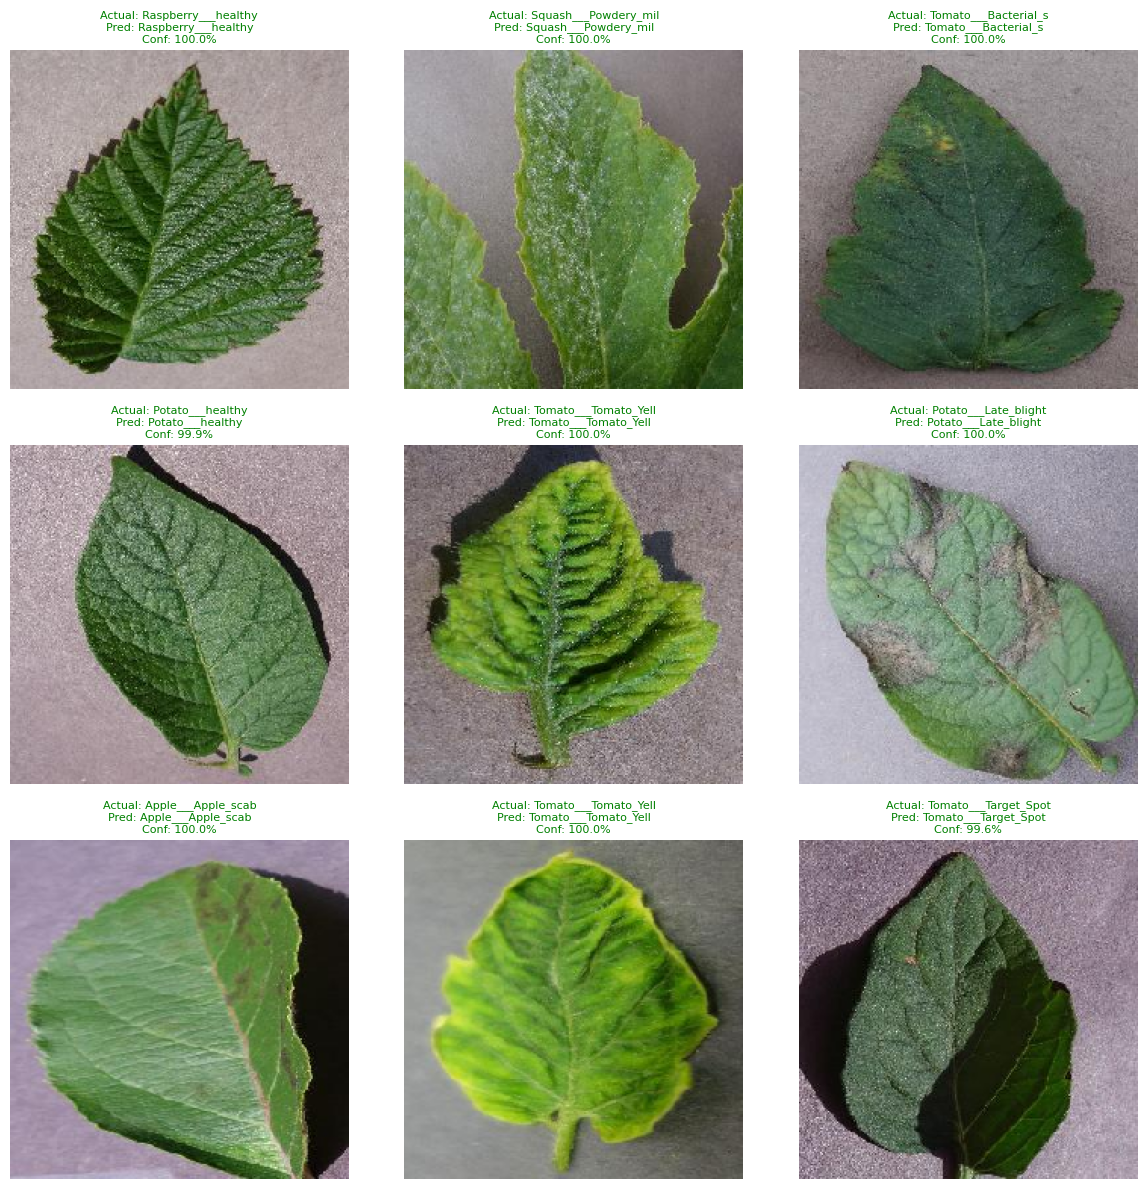

✅ Test results saved!


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import json
from tensorflow.keras.preprocessing import image

# Load class names
with open(f'{PROJECT_DIR}/models/class_names.json', 'r') as f:
    class_names = json.load(f)

# Load TFLite model
interpreter = tf.lite.Interpreter(
    model_path=f'{PROJECT_DIR}/models/plant_disease_model.tflite'
)
interpreter.allocate_tensors()
input_details = interpreter.get_input_details()
output_details = interpreter.get_output_details()

# Hàm predict 1 ảnh
def predict_image(img_path):
    img = image.load_img(img_path, target_size=(224, 224))
    img_array = image.img_to_array(img) / 255.0
    img_array = np.expand_dims(img_array, axis=0).astype(np.float32)

    interpreter.set_tensor(input_details[0]['index'], img_array)
    interpreter.invoke()
    output = interpreter.get_tensor(output_details[0]['index'])[0]

    predicted_idx = str(np.argmax(output))
    confidence = output[int(predicted_idx)] * 100
    predicted_class = class_names[predicted_idx]

    return predicted_class, confidence

# Test 9 ảnh ngẫu nhiên
import random, os

PREPARED_DIR = '/content/drive/MyDrive/SIT210_PlantDisease/dataset/prepared'
test_dir = f'{PREPARED_DIR}/test'

fig, axes = plt.subplots(3, 3, figsize=(12, 12))
axes = axes.flatten()

for i in range(9):
    # Random class và ảnh
    cls = random.choice(os.listdir(test_dir))
    img_file = random.choice(os.listdir(f'{test_dir}/{cls}'))
    img_path = f'{test_dir}/{cls}/{img_file}'

    # Predict
    predicted, confidence = predict_image(img_path)
    actual = cls

    # Hiển thị
    img = image.load_img(img_path, target_size=(224, 224))
    axes[i].imshow(img)

    correct = predicted == actual
    color = 'green' if correct else 'red'
    axes[i].set_title(
        f'Actual: {actual[:20]}\nPred: {predicted[:20]}\nConf: {confidence:.1f}%',
        color=color, fontsize=8
    )
    axes[i].axis('off')

plt.tight_layout()
plt.savefig(f'{PROJECT_DIR}/models/test_results.png')
plt.show()
print("✅ Test results saved!")

In [ ]:
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 5))
plt.plot(history.history['accuracy'], label='Training accuracy')
plt.plot(history.history['val_accuracy'], label='Validation accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('PlantVillage MobileNetV2 — Training Progress')
plt.legend()
plt.grid(True, alpha=0.3)
plt.savefig('training_curve.png', dpi=100, bbox_inches='tight')
plt.show()

NameError: name 'history' is not defined

<Figure size 1000x500 with 0 Axes>

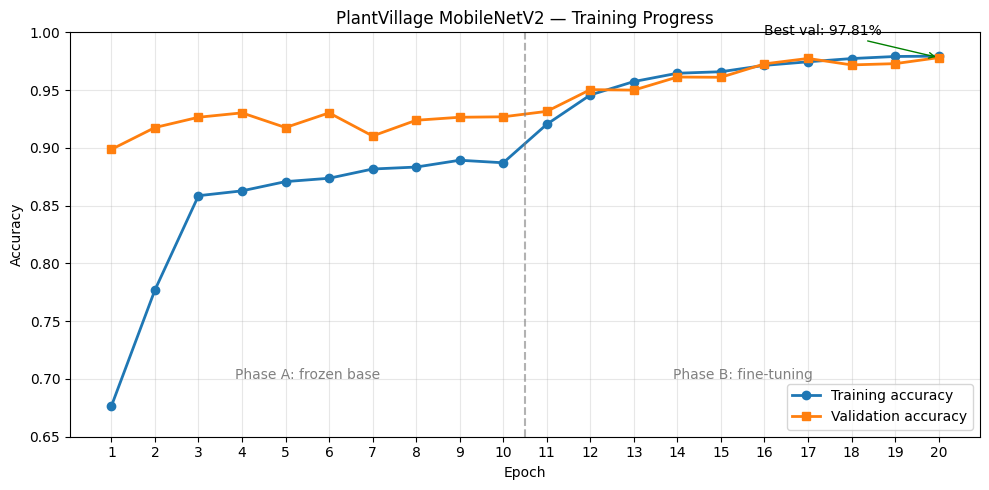

In [ ]:
import matplotlib.pyplot as plt

# Phase A: frozen base (10 epochs)
phase_a_train = [0.6765, 0.7770, 0.8586, 0.8628, 0.8708,
                 0.8737, 0.8817, 0.8834, 0.8893, 0.8871]
phase_a_val   = [0.8987, 0.9176, 0.9265, 0.9303, 0.9176,
                 0.9303, 0.9103, 0.9239, 0.9265, 0.9269]

# Phase B: fine-tune (10 epochs)
phase_b_train = [0.9204, 0.9458, 0.9574, 0.9646, 0.9659,
                 0.9714, 0.9745, 0.9773, 0.9791, 0.9794]
phase_b_val   = [0.9316, 0.9504, 0.9500, 0.9613, 0.9611,
                 0.9727, 0.9774, 0.9718, 0.9729, 0.9781]

# Concatenate both phases, x-axis = 1..20
epochs = list(range(1, 21))
train_acc = phase_a_train + phase_b_train
val_acc   = phase_a_val   + phase_b_val

plt.figure(figsize=(10, 5))
plt.plot(epochs, train_acc, 'o-', label='Training accuracy', linewidth=2)
plt.plot(epochs, val_acc,   's-', label='Validation accuracy', linewidth=2)

# Mark where fine-tuning starts
plt.axvline(x=10.5, color='gray', linestyle='--', alpha=0.6)
plt.text(5.5,  0.70, 'Phase A: frozen base',  ha='center', fontsize=10, color='gray')
plt.text(15.5, 0.70, 'Phase B: fine-tuning',  ha='center', fontsize=10, color='gray')

# Highlight best val accuracy
best_val = max(val_acc)
best_epoch = epochs[val_acc.index(best_val)]
plt.annotate(f'Best val: {best_val:.2%}',
             xy=(best_epoch, best_val),
             xytext=(best_epoch - 4, best_val + 0.02),
             fontsize=10,
             arrowprops=dict(arrowstyle='->', color='green'))

plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('PlantVillage MobileNetV2 — Training Progress')
plt.legend(loc='lower right')
plt.grid(True, alpha=0.3)
plt.ylim(0.65, 1.0)
plt.xticks(epochs)
plt.tight_layout()
plt.savefig('training_curve.png', dpi=120, bbox_inches='tight')
plt.show()